# Importing required libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [7]:
df=pd.read_csv('diabetes.csv')
print("Dataset loaded successfully")

Dataset loaded successfully


In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
#Statistical Summary of the dataset
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
#Datatype information or summary about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
#Checking for null values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Exploratory Data Analysis (EDA)

C:\Users\Shivraj\AppData\Local\Temp\ipykernel_2428\2795211970.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='viridis')


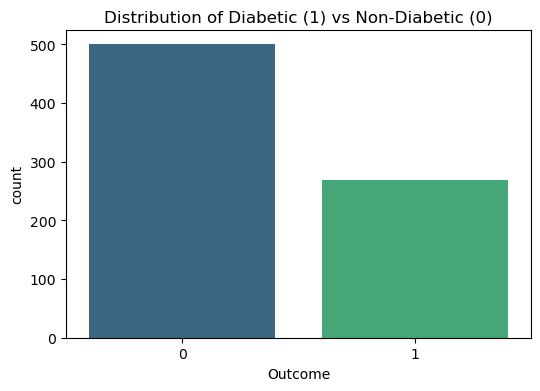

In [9]:
#Exploratory data analysis of the given dataset
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='viridis')
plt.title('Distribution of Diabetic (1) vs Non-Diabetic (0)')
plt.show()

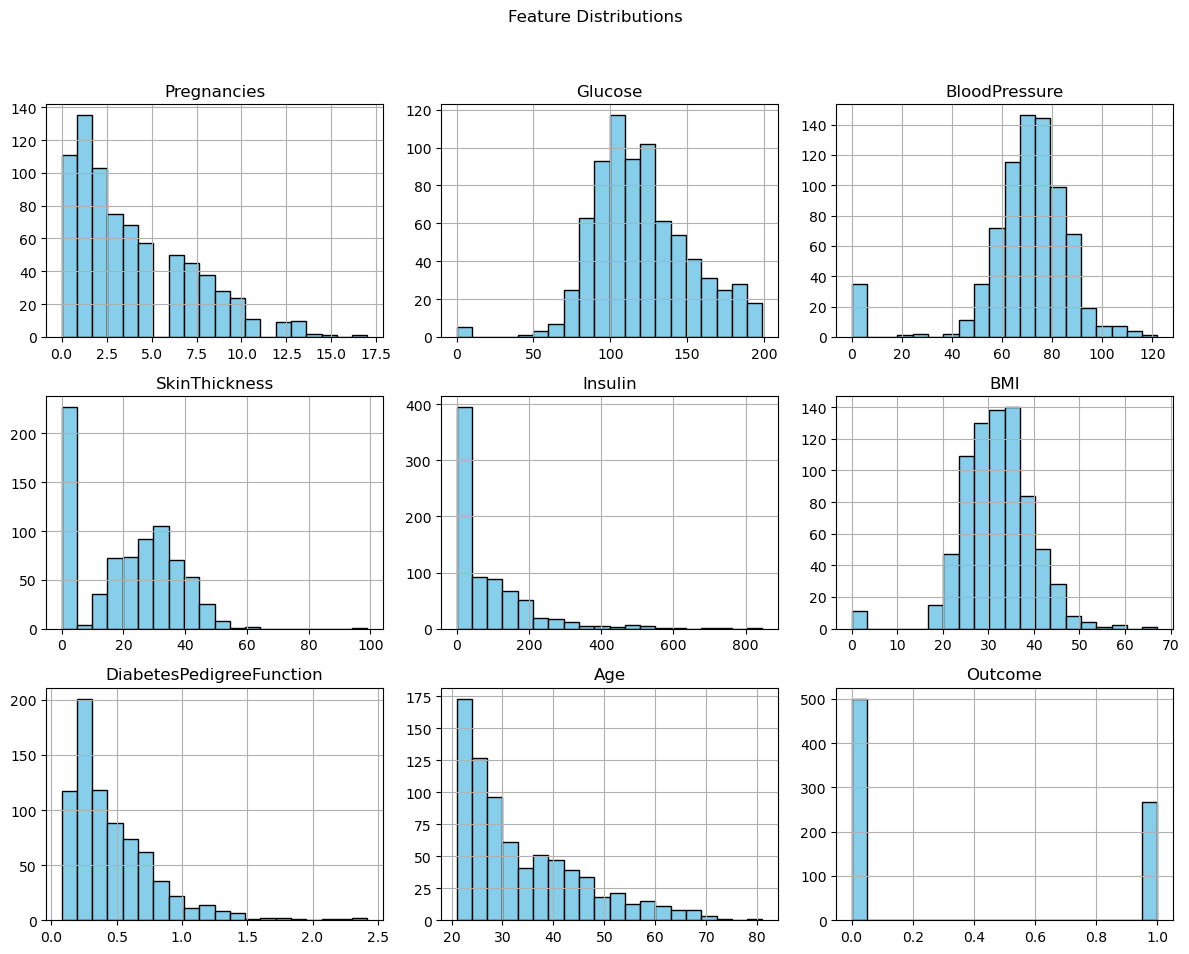

In [10]:
### STEP 3: Feature Distributions (Histograms)
df.hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

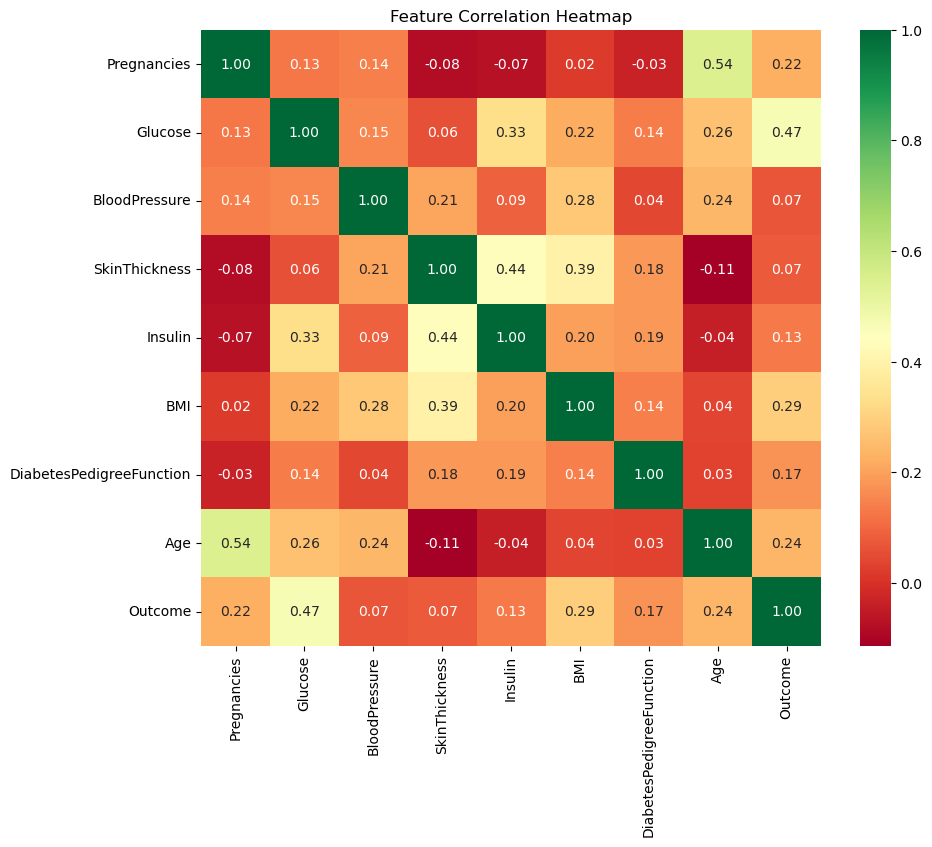

In [11]:
### STEP 4: Correlation Analysis
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

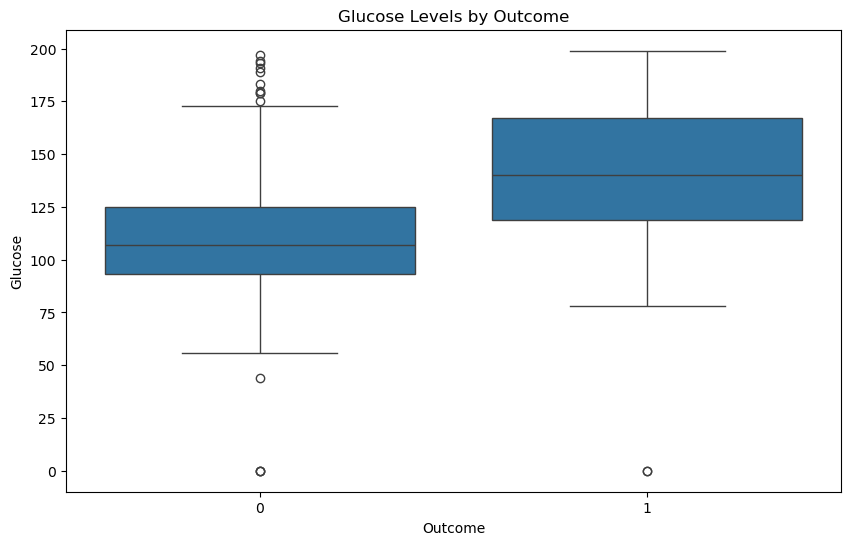

In [12]:
### STEP 5: Relationship with Outcome (Boxplots)
# This shows how a feature's range differs for diabetic vs non-diabetic
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose Levels by Outcome')
plt.show()

In [13]:
# Create a copy to keep original data safe
df_clean = df.copy()

# List of columns where 0 is actually a missing value
cols_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN so they don't skew the median calculation
for col in cols_fix:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Impute NaN values based on the Median of the Outcome class
# This prevents 'data leakage' from the healthy group to the diabetic group
for col in cols_fix:
    df_clean[col] = df_clean[col].fillna(df_clean.groupby('Outcome')[col].transform('median'))

print("Missing values after advanced imputation:\n", df_clean.isnull().sum().sum())

Missing values after advanced imputation:
 0


In [14]:
# 1. Body Mass Index Category (Ordinal Encoding)
# Underweight, Normal, Overweight, Obese
df_clean['BMI_Cat'] = pd.cut(df_clean['BMI'], bins=[0, 18.5, 24.9, 29.9, 100], labels=[1, 2, 3, 4])

# 2. Glucose-Insulin Ratio
# A high ratio can indicate insulin resistance
df_clean['Glucose_Insulin_Ratio'] = df_clean['Glucose'] / (df_clean['Insulin'] + 1)

# 3. High Risk Interaction
# Age * Glucose often shows a stronger correlation than either alone
df_clean['Age_Glucose'] = df_clean['Age'] * df_clean['Glucose']

print(df_clean[['BMI_Cat', 'Glucose_Insulin_Ratio', 'Age_Glucose']].head())

  BMI_Cat  Glucose_Insulin_Ratio  Age_Glucose
0       4               0.868035       7400.0
1       3               0.821256       2635.0
2       2               1.073314       5856.0
3       3               0.936842       1869.0
4       4               0.810651       4521.0


C:\Users\Shivraj\AppData\Local\Temp\ipykernel_2428\1687242427.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y='Glucose', data=df_clean, split=True, inner="quart", palette="Set2")
C:\Users\Shivraj\AppData\Local\Temp\ipykernel_2428\1687242427.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y='BMI', data=df_clean, split=True, inner="quart", palette="Set3")


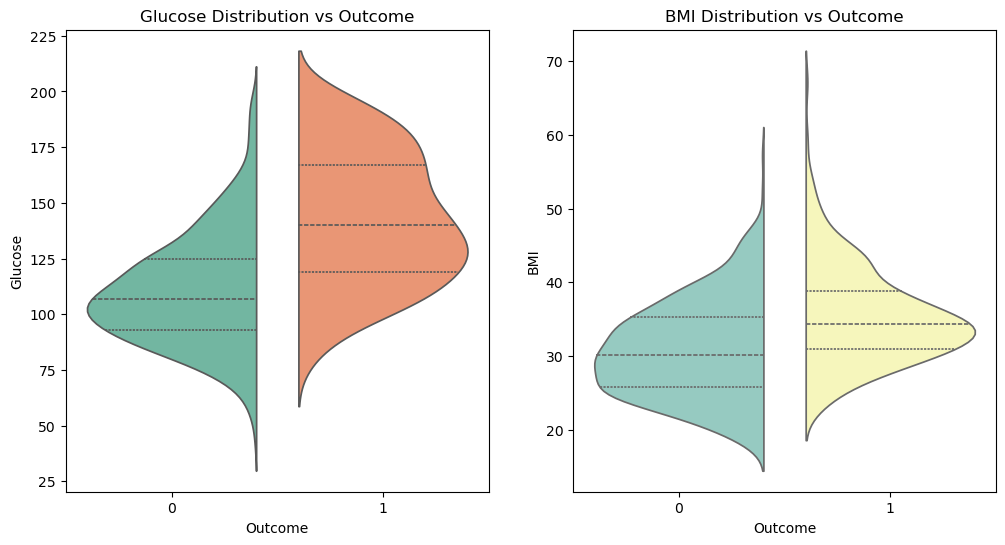

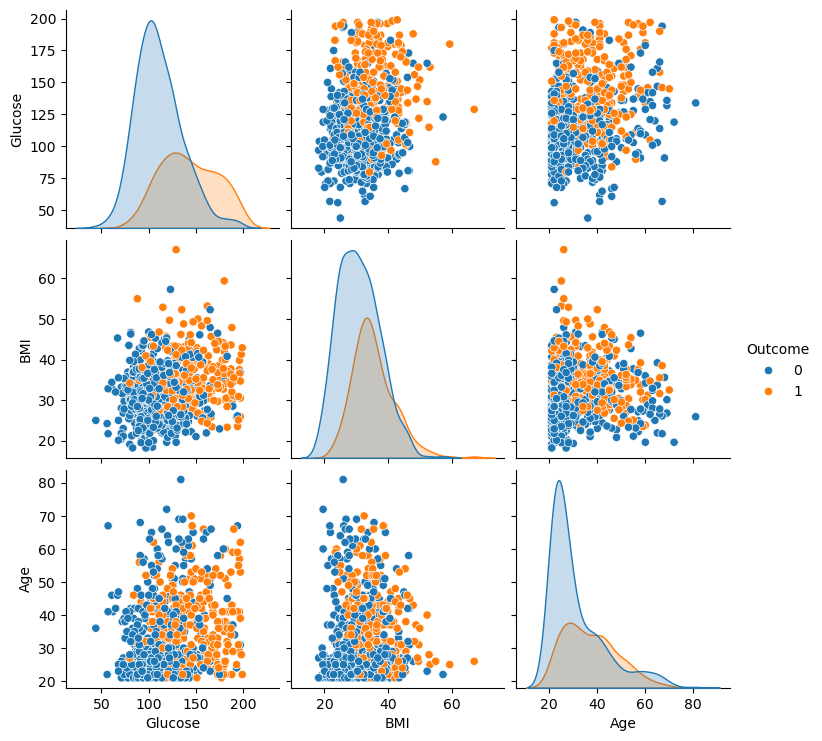

In [15]:
# Violin Plot to show distribution spread between Diabetic and Non-Diabetic
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.violinplot(x='Outcome', y='Glucose', data=df_clean, split=True, inner="quart", palette="Set2")
plt.title('Glucose Distribution vs Outcome')

plt.subplot(1, 2, 2)
sns.violinplot(x='Outcome', y='BMI', data=df_clean, split=True, inner="quart", palette="Set3")
plt.title('BMI Distribution vs Outcome')
plt.show()

# Pairplot (Take a sample to avoid lag)
# This shows how features interact in clusters
sns.pairplot(df_clean[['Glucose', 'BMI', 'Age', 'Outcome']], hue='Outcome', diag_kind='kde')
plt.show()

In [17]:
df_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Cat,Glucose_Insulin_Ratio,Age_Glucose
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,4,0.868035,7400.0
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,3,0.821256,2635.0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,2,1.073314,5856.0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,3,0.936842,1869.0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,4,0.810651,4521.0


In [21]:
# 1. Separate Features and Target
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']



In [22]:
# 2. Train test spliting the data(80% train and 20% test)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [23]:
# 3. Standardization (Handling Data Leakage)
scaler = StandardScaler()

In [24]:
# Fit only on X_train, transform both
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


# Logistic Regression Model

In [25]:
#Fitting the logistic Regression model here
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and Train
lr_model = LogisticRegression(C=1.0, solver='liblinear', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predict
lr_pred = lr_model.predict(X_test_scaled)

# Evaluate
print("--- Logistic Regression Report ---")
print(classification_report(y_test, lr_pred))

# Visualizing Coefficients (Optional but great for projects)
# This shows which features push the model toward a "Diabetic" result
importance = lr_model.coef_[0]
for i,v in enumerate(importance):
    print(f'Feature: {X.columns[i]}, Score: {v:.4f}')

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        99
           1       0.67      0.67      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154

Feature: Pregnancies, Score: 0.1906
Feature: Glucose, Score: 1.2778
Feature: BloodPressure, Score: -0.1181
Feature: SkinThickness, Score: 0.4021
Feature: Insulin, Score: 0.0660
Feature: BMI, Score: 0.1778
Feature: DiabetesPedigreeFunction, Score: 0.2486
Feature: Age, Score: 0.6607
Feature: BMI_Cat, Score: 0.4530
Feature: Glucose_Insulin_Ratio, Score: -0.4786
Feature: Age_Glucose, Score: -0.3648


# Decision Tree Classifier

--- Decision Tree Report ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        99
           1       0.84      0.78      0.81        55

    accuracy                           0.87       154
   macro avg       0.86      0.85      0.86       154
weighted avg       0.87      0.87      0.87       154



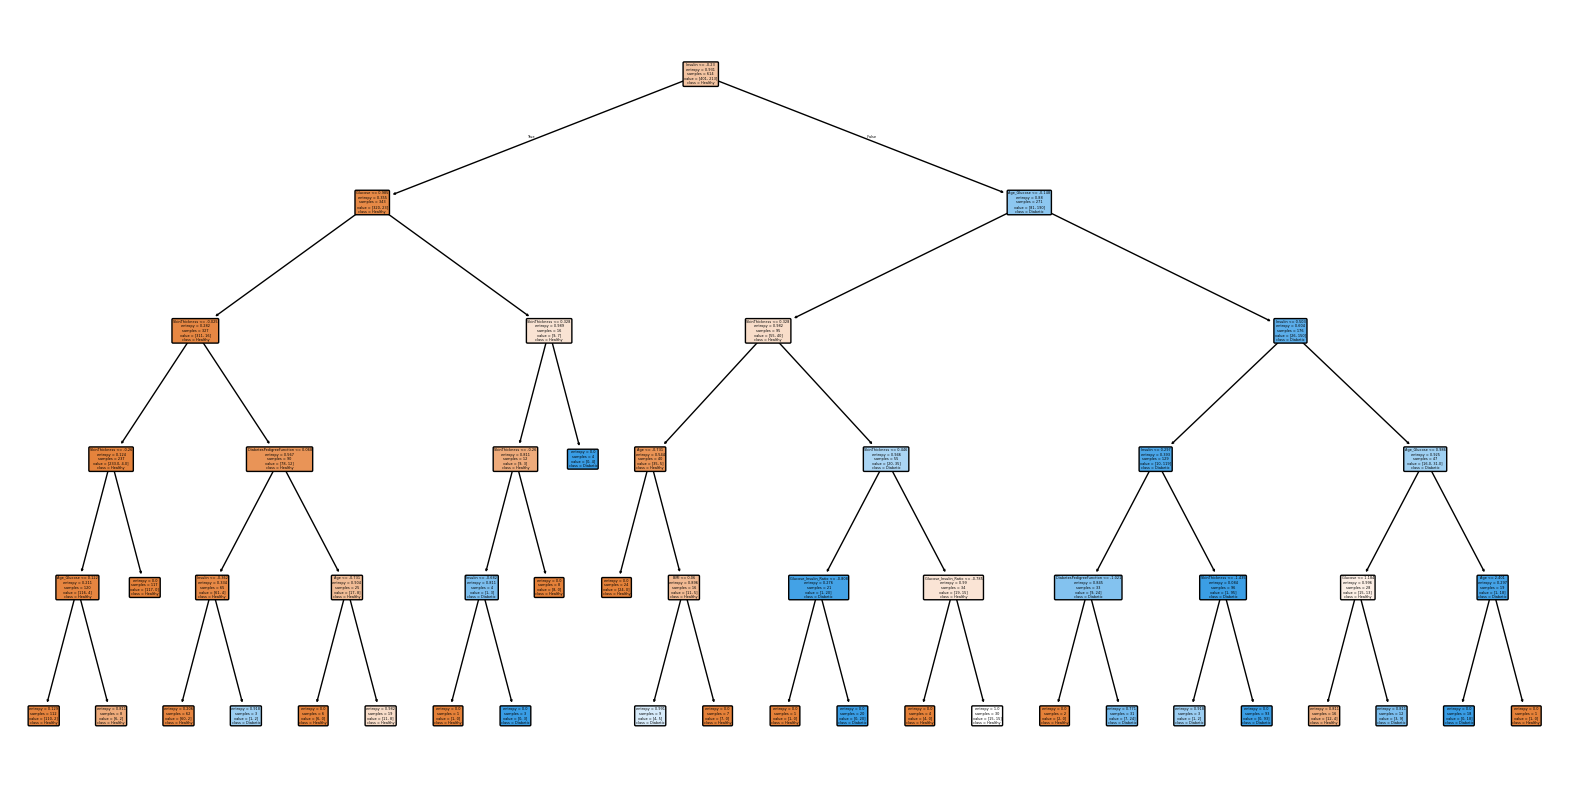

In [28]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initialize and Train
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predict
dt_pred = dt_model.predict(X_test_scaled)

# Evaluate
print("--- Decision Tree Report ---")
print(classification_report(y_test, dt_pred))

# Plot the Tree (Very impressive for your project report)
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Healthy', 'Diabetic'], filled=True, rounded=True)
plt.show()

# Random Forest classifier

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        99
           1       0.77      0.80      0.79        55

    accuracy                           0.84       154
   macro avg       0.83      0.83      0.83       154
weighted avg       0.85      0.84      0.84       154



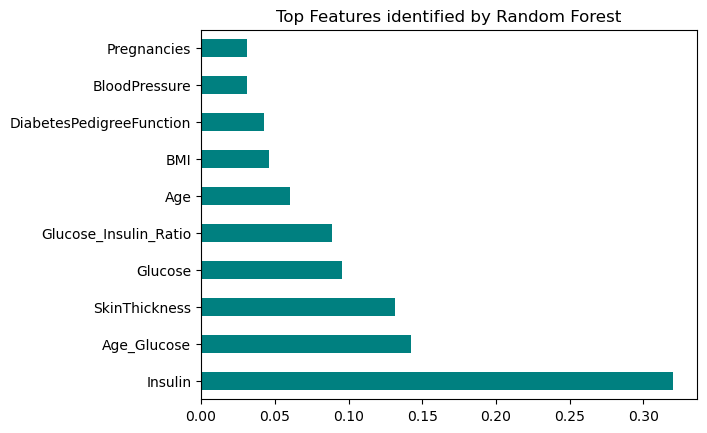

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and Train
rf_model = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict
rf_pred = rf_model.predict(X_test_scaled)

# Evaluate
print("--- Random Forest Report ---")
print(classification_report(y_test, rf_pred))

# Feature Importance Plot
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top Features identified by Random Forest')
plt.show()

## Comparing the models

In [31]:
# 1. Dictionary to store the scores
train_test_results = []

# List of your previously defined models
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

# 2. Calculate Accuracies
for name, model in models.items():
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    
    train_test_results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Gap": train_acc - test_acc
    })

# 3. Create DataFrame
comparison_df = pd.DataFrame(train_test_results)
print(comparison_df)

                 Model  Train Accuracy  Test Accuracy       Gap
0  Logistic Regression        0.793160       0.766234  0.026926
1        Decision Tree        0.920195       0.870130  0.050066
2        Random Forest        1.000000       0.844156  0.155844


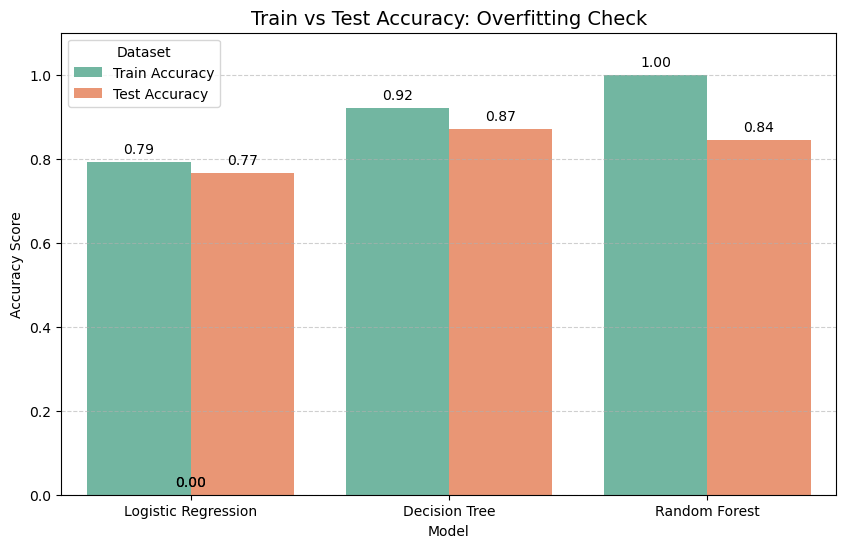

In [33]:
# Melt the data for plotting
plot_df = comparison_df.melt(id_vars="Model", value_vars=["Train Accuracy", "Test Accuracy"], 
                              var_name="Dataset", value_name="Accuracy")

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Model', y='Accuracy', hue='Dataset', palette='Set2')

plt.title('Train vs Test Accuracy: Overfitting Check', fontsize=14)
plt.ylim(0, 1.1) # Set y-axis to show 0% to 110% for clarity
plt.ylabel('Accuracy Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adding the values on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points')

plt.show()

# Final Outcome 

The Decision tree is the best model for the Given Dataset since the Random forest model is giving 100% accuracy on train dataset
which is the worst case in machine learning models it means the rf model is learning each and every pattern including noise from the dataset

# Sample Data point check

In [35]:


# Creating two samples: 
# Sample 1: Low Glucose, Normal BMI, Younger (Likely Healthy)
# Sample 2: High Glucose, High BMI, Older (Likely Diabetic)

sample_data = pd.DataFrame([
    [2, 95, 70, 20, 80, 24.5, 0.25, 25, 2, 1.18, 2375], # Healthy
    [8, 180, 90, 45, 300, 38.2, 1.5, 55, 4, 0.60, 9900]   # High Risk
], columns=X.columns) # X.columns contains all 11 features including engineered ones

print("Sample Data for Testing:")
print(sample_data)

Sample Data for Testing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            2       95             70             20       80  24.5   
1            8      180             90             45      300  38.2   

   DiabetesPedigreeFunction  Age  BMI_Cat  Glucose_Insulin_Ratio  Age_Glucose  
0                      0.25   25        2                   1.18         2375  
1                      1.50   55        4                   0.60         9900  


In [36]:
# 1. Scale the sample data using the SAME scaler from training
sample_scaled = scaler.transform(sample_data)

# 2. Make Predictions
predictions = dt_model.predict(sample_scaled)
probabilities = dt_model.predict_proba(sample_scaled)

# 3. Output Results
for i, pred in enumerate(predictions):
    status = "Diabetic" if pred == 1 else "Healthy"
    confidence = probabilities[i][pred] * 100
    print(f"\nPatient {i+1} Result: {status}")
    print(f"Model Confidence: {confidence:.2f}%")


Patient 1 Result: Healthy
Model Confidence: 98.21%

Patient 2 Result: Diabetic
Model Confidence: 100.00%


In [37]:
# Optional: See which features triggered the decision
node_indicator = dt_model.decision_path(sample_scaled)
leaf_id = dt_model.apply(sample_scaled)

print(f"\nPatient 1 ended in Leaf Node: {leaf_id[0]}")
print(f"Patient 2 ended in Leaf Node: {leaf_id[1]}")


Patient 1 ended in Leaf Node: 5
Patient 2 ended in Leaf Node: 49


# Saving the model in a pkl file

In [ ]:
import pickle

# 1. Save the Decision Tree Model
with open('diabetes_dt_model.pkl', 'wb') as model_file:
    pickle.dump(dt_model, model_file)

# 2. Save the Scaler (CRITICAL STEP)
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("Model and Scaler saved successfully as .pkl files!")